In [1]:
!pip install face_recognition cmake dlib

/opt/conda/envs/py310/lib/python3.10/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Number of faces detected: 1


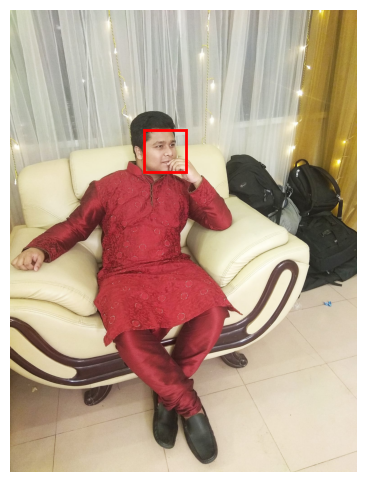

In [2]:
import face_recognition
import matplotlib.pyplot as plt

# Load image
image = face_recognition.load_image_file("known/saifur/3.jpg")

# Detect face locations
face_locations = face_recognition.face_locations(image)

print("Number of faces detected:", len(face_locations))

# Display image with bounding boxes
plt.figure(figsize=(8,6))
plt.imshow(image)
plt.axis("off")

# Draw boxes
for (top, right, bottom, left) in face_locations:
    plt.gca().add_patch(
        plt.Rectangle((left, top), right-left, bottom-top,
                      fill=False, edgecolor='red', linewidth=2)
    )

plt.show()


In [3]:
import face_recognition

known_image = face_recognition.load_image_file("known/saifur/3.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]

unknown_image = face_recognition.load_image_file("known/saifur/2.jpg")
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

# Compute distance
distance = face_recognition.face_distance([known_encoding], unknown_encoding)[0]
print("Distance:", distance)

# Set your own threshold
threshold = 0.45   # best range = 0.40 - 0.50

if distance <= threshold:
    print("Match found!")
else:
    print("Not a match.")


Distance: 0.37291755022592354
Match found!
